# ML-10 — Content Action Playbook

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Ranked actions + reason codes

*The queue: what to do first, and why, in words a human trusts.*

The queue is built from **w04's baseline score**, not w05's models -- w06 confirmed the
baseline wins decisively against April's real outcome (precision@30: 0.433 vs. 0.100 vs.
0.000), so the better-performing, more explainable method is what actually ships here.

Reason code and action stay from w04 (`ctr_below_position_expectation`,
`review_title_meta`), but each row also gets an **archetype**, informed by w04's own
weak-picks finding (the spike-day concentration issue):

- `high_impact_underperformer`: visible, positive gap, stable position all month -- the
  clean, trustworthy candidates.
- `spike_driven_unstable`: visible, positive gap, but more than half the month's impressions
  came from a cluster of anomalous days -- flagged, but needs a human look before trusting
  the "premium position" the score is built on.
- `stable_modest_gap`: visible, a real but smaller gap -- worth a look, lower priority.
- `not_flagged`: not visible (below the volume gate) or already at/above its tier's expected
  CTR -- no action.

In [7]:
import duckdb
import pandas as pd
import numpy as np
import json as json_lib
from google.colab import userdata

con = duckdb.connect()
HF_TOKEN = userdata.get("HF_TOKEN")
con.execute(f"CREATE SECRET (TYPE huggingface, TOKEN '{HF_TOKEN}')")

rel = "hf://datasets/FlyRank/internship-warehouse"

month_03 = con.sql(f"""
    SELECT *
    FROM read_parquet('{rel}/fact_content_daily_performance/month=2026-03/data_0.parquet')
    WHERE gsc_data_available IS TRUE
""").df()

# --- Same page-month pipeline as w04/w05/w06: position fix, ctr_gap, visible, baseline score ---
page_month = month_03.groupby(["client_hash_id", "content_hash_id"], as_index=False).agg(
    total_impressions=("gsc_impressions", "sum"),
    total_clicks=("gsc_clicks", "sum"),
    days_with_data=("report_date", "count"),
)

valid_position_rows = month_03[month_03["gsc_avg_position"] > 0].copy()
valid_position_rows["_weight"] = valid_position_rows["gsc_impressions"].clip(lower=1)
valid_position_rows["_weighted_pos"] = valid_position_rows["gsc_avg_position"] * valid_position_rows["_weight"]
grouped_sums = valid_position_rows.groupby(
    ["client_hash_id", "content_hash_id"], as_index=False
)[["_weighted_pos", "_weight"]].sum()
grouped_sums["avg_position"] = grouped_sums["_weighted_pos"] / grouped_sums["_weight"]

page_month = page_month.merge(
    grouped_sums[["client_hash_id", "content_hash_id", "avg_position"]],
    on=["client_hash_id", "content_hash_id"], how="left"
)
page_month = page_month[page_month["avg_position"].notna()].copy()

page_month["ctr_pct"] = np.where(
    page_month["total_impressions"] > 0,
    page_month["total_clicks"] / page_month["total_impressions"] * 100,
    np.nan
)

month_03["day_median"] = month_03.groupby(
    ["client_hash_id", "content_hash_id"]
)["gsc_impressions"].transform("median").clip(lower=1)
month_03["is_spike_day"] = month_03["gsc_impressions"] > 5 * month_03["day_median"]
spike_share_all = month_03.groupby(
    ["client_hash_id", "content_hash_id"]
)[["gsc_impressions", "is_spike_day"]].apply(
    lambda g: g.loc[g["is_spike_day"], "gsc_impressions"].sum() / g["gsc_impressions"].sum()
).reset_index(name="spike_day_share")
page_month = page_month.merge(spike_share_all, on=["client_hash_id", "content_hash_id"], how="left")
page_month["spike_day_share"] = page_month["spike_day_share"].fillna(0.0)

page_month["position_tier"] = pd.cut(
    page_month["avg_position"], bins=[0, 3, 10, 20, 1000],
    labels=["1-3", "4-10", "11-20", "21+"]
)
MIN_IMPRESSIONS = 500
page_month["visible"] = (page_month["total_impressions"] >= MIN_IMPRESSIONS).astype(int)
tier_baseline = page_month[page_month["visible"] == 1].groupby(
    "position_tier", observed=True
)["ctr_pct"].median()
expected_ctr = page_month["position_tier"].astype(str).map(tier_baseline.to_dict()).astype(float)
page_month["ctr_gap"] = expected_ctr - page_month["ctr_pct"]
page_month["baseline_score"] = page_month["visible"] * page_month["total_impressions"] * page_month["ctr_gap"].clip(lower=0)

# --- Archetype assignment ---
SPIKE_THRESHOLD = 0.5

def assign_archetype(row):
    if row["visible"] == 0 or row["ctr_gap"] <= 0:
        return "not_flagged"
    if row["spike_day_share"] > SPIKE_THRESHOLD:
        return "spike_driven_unstable"
    if row["baseline_score"] > 0:
        return "high_impact_underperformer" if row["total_impressions"] >= 5000 else "stable_modest_gap"
    return "not_flagged"

page_month["archetype"] = page_month.apply(assign_archetype, axis=1)
page_month["reason_code"] = "ctr_below_position_expectation"

archetype_actions = {
    "high_impact_underperformer": "review_title_meta",
    "spike_driven_unstable": "monitor_before_acting",
    "stable_modest_gap": "review_title_meta_low_priority",
    "not_flagged": "no_action",
}
page_month["action"] = page_month["archetype"].map(archetype_actions)

ranked = page_month.sort_values("baseline_score", ascending=False).reset_index(drop=True)

print("Archetype distribution:")
print(ranked["archetype"].value_counts())
print()
print(ranked[ranked["archetype"] != "not_flagged"][
    ["client_hash_id", "content_hash_id", "avg_position", "total_impressions", "days_with_data",
     "ctr_gap", "spike_day_share", "baseline_score", "archetype", "reason_code", "action"]
].head(10).to_string(index=False))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Archetype distribution:
archetype
not_flagged                   144345
stable_modest_gap              24037
high_impact_underperformer      5755
spike_driven_unstable           1167
Name: count, dtype: int64

         client_hash_id          content_hash_id  avg_position  total_impressions  days_with_data  ctr_gap  spike_day_share  baseline_score                  archetype                    reason_code                action
client_23a62021009f63c4 content_44f34c0a90047651      0.665877             212404              31 0.225294         0.954525    47853.312303      spike_driven_unstable ctr_below_position_expectation monitor_before_acting
client_73cda7b4e4f265ea content_8e1334d6356668e3      2.693038             134984              31 0.235852         0.482428    31836.277603 high_impact_underperformer ctr_below_position_expectation     review_title_meta
client_73cda7b4e4f265ea content_fec55986a1868d62      0.308426             124075              31 0.235787         0.989950    2925

## 2. Intended use and limits

*Who uses this, for what — and where it stops being valid.*

**Intended use:** a content reviewer with limited weekly capacity uses this queue to decide
which pages to check first for a title/meta/engagement fix. It is a triage aid, not an
automated action -- every row still needs the human review in Section 3 before anything
changes on a live page.

**Limits, stated plainly:**
- This is a single-month (March 2026) snapshot from one lane of one dataset. It observed a
  pattern in this data, this period -- it does not predict, and should not be read as
  predicting, how any specific page will perform going forward.
- w05/w06 showed a structural model actually underperforms this rule on a real forward test
  (April outcome); the rule's own strength comes from directly measuring March's real CTR,
  not from forecasting -- it says nothing about pages outside this month's data.
- `spike_driven_unstable` rows are flagged with a known caveat already, not a clean recommendation.
- No causal claim is supported anywhere here: this is cross-sectional, observational data.
  A page ranking high on this queue is *associated with* a gap versus its position tier --
  fixing it is not guaranteed, by this data, to close that gap.
- The decay/refresh timing context in this playbook (Section 4) is borrowed from the
  portfolio-level FlyRank research paper's own validated findings, not something re-derived
  from this lane's own data -- it informs *when* to act, not a claim this lane's model
  produced independently.

## 3. Human review + the no-go list

*What a person must check before acting. What should never be automated.*

**Before acting on any flagged row, a human must check:**
- `spike_day_share` -- if it's above 0.5, look at the raw daily rows before trusting the
  monthly position (per w04's finding, a handful of anomalous days can make a page look like
  it holds a premium position it doesn't hold most of the month).
- Whether the low CTR reflects a fixable title/meta/snippet issue, or a genuine intent
  mismatch a metadata change can't solve -- this queue can't distinguish the two.
- `total_impressions` and `days_with_data` coverage for the month -- a partial month (a page
  that only appears for part of March) makes the gap estimate less reliable.

**No-go list -- never automate these:**
- Never auto-publish a title/meta/content change from this queue -- every action needs a
  human editor's judgment call.
- Never use this queue as the sole input to a client-facing report without disclosing it's a
  single-month, observational rule, not a validated forecast.
- Never treat `spike_driven_unstable` rows as confirmed opportunities without the raw-data
  check above.
- Never use this output for compensation, personnel, or vendor decisions -- it was built to
  rank pages, not people or teams.
- Never apply this queue to a client with too little history this month to trust
  (see w03's data-contract limits: uneven `gsc_data_start` per client).

In [8]:
# Quick, concrete check supporting the review guidance above: how many flagged rows
# actually need the spike-day caveat before a human trusts them.
flagged = ranked[ranked["archetype"] != "not_flagged"]
print("Flagged rows by archetype:")
print(flagged["archetype"].value_counts())
print(f"\nShare of all flagged rows needing the spike-day check: "
      f"{(flagged['archetype'] == 'spike_driven_unstable').mean():.1%}")

Flagged rows by archetype:
archetype
stable_modest_gap             24037
high_impact_underperformer     5755
spike_driven_unstable          1167
Name: count, dtype: int64

Share of all flagged rows needing the spike-day check: 3.8%


## 4. Monitoring / retrain triggers

*What would tell you the recommendations went stale?*

**Decay/refresh insight (borrowed context, per Section 2):** the FlyRank research paper's own
validated findings put content's peak performance at 61-90 days, with a decay cliff between
271-365 days, and found that a page refreshed within 30 days of the 365+ mark showed a 3.2x
health boost and 57x impression boost in that portfolio. That's directional evidence, from a
different (though related) dataset -- it suggests flagged pages here should be reviewed
promptly rather than left in a queue, since staleness compounds; it is not a claim this
lane's own data validated independently.

**Monitoring triggers -- this playbook should be treated as stale if:**
- The position-tier baseline (the expected-CTR lookup) shifts meaningfully month to month --
  re-run Section 1's tier baseline calculation on each new month rather than reusing March's.
- The share of `spike_driven_unstable` rows grows well beyond what's seen here -- a rising
  share would mean the spike-day pattern is becoming the norm, not the exception, and the
  volume-gate threshold (500 impressions) may need revisiting.
- A forward check like w06's (comparing this month's flags against next month's real outcome)
  shows precision@K dropping toward the base rate -- that would mean the rule stopped adding
  lift over random ranking.
- Client mix changes materially (new clients added, old ones dropped) -- the tier baseline is
  computed across all visible clients, so a shift in composition changes what "expected CTR"
  means without any code changing.

**Cost/value framing -- primarily qualitative, by necessity.** A `clicks x cpc` dollar proxy
(the paper's own defensible formula, Finding #9) was tested against `dim_content`, but the
diagnostic below shows 76% of the queue has no usable `cpc` (67.2% exactly zero, 8.8% no
match at all) -- almost certainly a missing-keyword-match placeholder, not genuine
zero-value content, since the paper's own portfolio averages put even informational content
at $0.15. With three-quarters of the queue unusable, a dollar figure would misrepresent most
rows rather than clarify them. The primary cost/value lens here is qualitative instead:
reviewer time is small and roughly fixed per page, so `total_impressions` and `ctr_gap`
already order the queue by scale of opportunity. `captured_value` is kept only as a
supplementary, narrow number for the minority of rows where `cpc` is confirmed nonzero --
never as a queue-wide dollar total.

In [9]:
dim_content = con.sql(f"SELECT * FROM read_parquet('{rel}/dim_content.parquet')").df()
print("dim_content columns:", sorted(dim_content.columns.tolist()))

# Join on content_hash_id -- confirm this key exists before trusting the merge.
if "content_hash_id" in dim_content.columns and "cpc" in dim_content.columns:
    value_lookup = dim_content[["content_hash_id", "cpc"]].drop_duplicates("content_hash_id")
    ranked_with_value = ranked.merge(value_lookup, on="content_hash_id", how="left")
    ranked_with_value["captured_value"] = ranked_with_value["total_clicks"] * ranked_with_value["cpc"]

    # Sanity check FIRST -- a cpc of exactly 0.00 across many high-traffic pages is
    # suspicious. The paper itself reports informational content averaging $0.15, not
    # $0.00, so this needs checking before the captured_value table is trusted at all.
    unmatched = ranked_with_value["cpc"].isna().sum()
    zero_cpc = (ranked_with_value["cpc"] == 0).sum()
    print(f"Rows with NO dim_content match (NaN cpc): {unmatched} of {len(ranked_with_value)}")
    print(f"Rows with cpc exactly 0.00: {zero_cpc} of {len(ranked_with_value)} "
          f"({zero_cpc / len(ranked_with_value):.1%})")
    print("A large zero-cpc share suggests 0 means 'no matched keyword value' for some")
    print("content, not a genuine zero-value page -- so the table below is restricted to")
    print("rows with a confirmed nonzero cpc, and captured_value is never used queue-wide.")

    confirmed_value_rows = ranked_with_value[
        (ranked_with_value["archetype"] != "not_flagged") & (ranked_with_value["cpc"] > 0)
    ]
    print(f"\nCaptured value (clicks x cpc), confirmed-nonzero-cpc flagged rows only "
          f"({len(confirmed_value_rows)} of {len(ranked_with_value[ranked_with_value['archetype'] != 'not_flagged'])} flagged rows qualify):")
    print(confirmed_value_rows[
        ["content_hash_id", "total_clicks", "cpc", "captured_value", "archetype"]
    ].head(10).to_string(index=False))

    print("\nThis is a proxy for value ALREADY captured this month, not projected value from")
    print("a fix -- how much additional value a review would generate is unmeasured here and")
    print("would need a monitored before/after window, per the paper's own 'Measure' steps.")
else:
    print("\ncontent_hash_id or cpc not found in dim_content -- skipping the dollar-value proxy.")
    print("Fall back to qualitative cost/value: reviewer time (fixed, small per page) against")
    print("total_impressions and ctr_gap as the scale of the opportunity, without a dollar figure.")

dim_content columns: ['backlinks', 'category_count', 'char_count', 'client_hash_id', 'competition', 'competition_level', 'content_created_date', 'content_hash_id', 'content_type', 'content_updated_date', 'cpc', 'is_deleted', 'is_published', 'keyword_char_count', 'keyword_created_date', 'keyword_hash_id', 'keyword_token_count', 'last_optimized_date', 'main_intent', 'model_used', 'optimization_eligible_date', 'provider_used', 'search_volume', 'url_char_count', 'url_hash_id', 'word_count']
Rows with NO dim_content match (NaN cpc): 15392 of 175304
Rows with cpc exactly 0.00: 117730 of 175304 (67.2%)
A large zero-cpc share suggests 0 means 'no matched keyword value' for some
content, not a genuine zero-value page -- so the table below is restricted to
rows with a confirmed nonzero cpc, and captured_value is never used queue-wide.

Captured value (clicks x cpc), confirmed-nonzero-cpc flagged rows only (7486 of 30959 flagged rows qualify):
         content_hash_id  total_clicks  cpc  captured

## 5. Exports for the paper

*Write the queue (and any figures you want to reuse) to work/outputs/ — your paper builds on these files.*

The queue CSV stays out of git by design (per the card, the CI leak-guard blocks data files
and this notebook regenerates it). The metrics JSON and figure both get committed --
they're the receipts the paper's numbers trace back to.

Queue written: 175304 rows -> work/outputs/action_playbook_queue.csv
Metrics written -> work/outputs/w07_metrics.json
{
  "month": "2026-03",
  "total_pages": 175304,
  "archetype_counts": {
    "not_flagged": 144345,
    "stable_modest_gap": 24037,
    "high_impact_underperformer": 5755,
    "spike_driven_unstable": 1167
  },
  "min_impressions_threshold": 500,
  "spike_threshold": 0.5,
  "baseline_precision_at_30_vs_april": 0.433,
  "model_precision_at_30_vs_april": 0.1
}


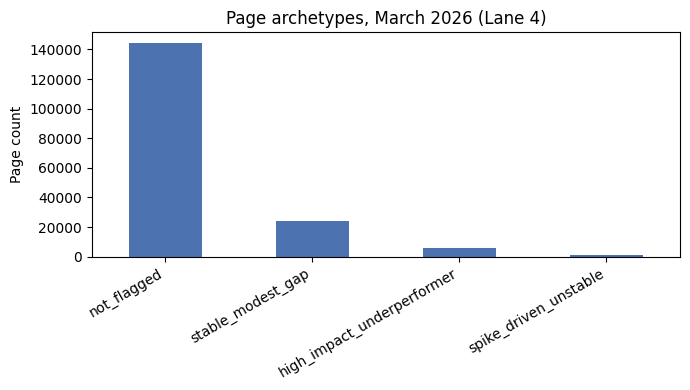

Figure written -> work/figures/archetype_distribution.png


In [10]:
import os
os.makedirs("work/outputs", exist_ok=True)
os.makedirs("work/figures", exist_ok=True)

output_cols = [
    "client_hash_id", "content_hash_id", "avg_position", "position_tier",
    "total_impressions", "total_clicks", "days_with_data", "ctr_pct", "ctr_gap",
    "spike_day_share", "baseline_score", "archetype", "reason_code", "action"
]
ranked[output_cols].to_csv("work/outputs/action_playbook_queue.csv", index=False)

metrics = {
    "month": "2026-03",
    "total_pages": int(len(ranked)),
    "archetype_counts": ranked["archetype"].value_counts().to_dict(),
    "min_impressions_threshold": MIN_IMPRESSIONS,
    "spike_threshold": SPIKE_THRESHOLD,
    "baseline_precision_at_30_vs_april": 0.433,  # from w05/w06's forward validation
    "model_precision_at_30_vs_april": 0.100,     # random forest, for reference -- baseline wins
}
with open("work/outputs/w07_metrics.json", "w") as f:
    json_lib.dump(metrics, f, indent=2, default=str)

print("Queue written:", len(ranked), "rows ->", "work/outputs/action_playbook_queue.csv")
print("Metrics written -> work/outputs/w07_metrics.json")
print(json_lib.dumps(metrics, indent=2, default=str))

# --- Figure: archetype distribution, committed to work/figures/ for paper reuse ---
import matplotlib.pyplot as plt

archetype_counts = ranked["archetype"].value_counts()
fig, ax = plt.subplots(figsize=(7, 4))
archetype_counts.plot(kind="bar", ax=ax, color="#4C72B0")
ax.set_title("Page archetypes, March 2026 (Lane 4)")
ax.set_ylabel("Page count")
ax.set_xlabel("")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig("work/figures/archetype_distribution.png", dpi=150)
plt.show()

print("Figure written -> work/figures/archetype_distribution.png")

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.